In [1]:
import sys
import os

sys.path.append(os.path.abspath('..')) 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from src.features.features import add_rolling_and_lags

%load_ext autoreload
%autoreload 2

In [4]:
df_train_clean = pd.read_csv("../data/processed/train_clean.csv")
df_test_clean = pd.read_csv("../data/processed/test_clean.csv")

print(df_train_clean.shape, df_test_clean.shape)
df_train_clean.head()

(20631, 19) (13096, 18)


,engine_number,cycle,setting_1,sensor_2,sensor_3,sensor_4,sensor_6,sensor_7,sensor_8,sensor_9,sensor_11,sensor_12,sensor_13,sensor_14,sensor_15,sensor_17,sensor_20,sensor_21,RUL_capped
0,1,1,-0.0007,641.82,1589.70,1400.60,21.61,554.36,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392,39.06,23.4190,130
1,1,2,0.0019,642.15,1591.82,1403.14,21.61,553.75,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392,39.00,23.4236,130
2,1,3,-0.0043,642.35,1587.99,1404.20,21.61,554.26,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390,38.95,23.3442,130
3,1,4,0.0007,642.35,1582.79,1401.87,21.61,554.45,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392,38.88,23.3739,130
4,1,5,-0.0019,642.37,1582.85,1406.22,21.61,554.00,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393,38.90,23.4044,130


In [5]:
df_train_features = add_rolling_and_lags(
    df_train_clean,
    windows=[5, 10],
    lags=[1, 3],
    drop_originals=True
)

print(df_train_features.shape)
df_train_features.head()

(20331, 94)
(20331, 94)


,engine_number,cycle,setting_1,RUL_capped,sensor_2_mean_5,sensor_2_std_5,sensor_3_mean_5,sensor_3_std_5,sensor_4_mean_5,sensor_4_std_5,...,sensor_8_lag_3,sensor_9_lag_3,sensor_11_lag_3,sensor_12_lag_3,sensor_13_lag_3,sensor_14_lag_3,sensor_15_lag_3,sensor_17_lag_3,sensor_20_lag_3,sensor_21_lag_3
0,1,4,0.0007,130,642.1675,0.250117,1588.075,3.855909,1402.4525,1.559645,...,2388.06,9046.19,47.47,521.66,2388.02,8138.62,8.4195,392.0,39.06,23.4190
1,1,5,-0.0019,130,642.2080,0.234776,1587.030,4.075678,1403.2060,2.159440,...,2388.04,9044.07,47.49,522.28,2388.07,8131.49,8.4318,392.0,39.00,23.4236
2,1,6,-0.0043,130,642.2640,0.128374,1585.984,3.885831,1402.7600,2.926337,...,2388.08,9052.94,47.27,522.42,2388.03,8133.23,8.4178,390.0,38.95,23.3442
3,1,7,0.0010,130,642.3300,0.139463,1586.084,4.075375,1401.6860,3.648360,...,2388.11,9049.48,47.13,522.86,2388.08,8133.83,8.3682,392.0,38.88,23.3739
4,1,8,-0.0034,130,642.3720,0.174270,1585.078,4.107952,1401.0400,3.367046,...,2388.06,9055.15,47.28,522.19,2388.04,8133.80,8.4294,393.0,38.90,23.4044


In [6]:
#what features did we end up with?
feature_cols = [col for col in df_train_features.columns 
                if col not in ['engine_number', 'cycle', 'RUL_capped']]
print(len(feature_cols))
print(feature_cols[:20])

91
['setting_1', 'sensor_2_mean_5', 'sensor_2_std_5', 'sensor_3_mean_5', 'sensor_3_std_5', 'sensor_4_mean_5', 'sensor_4_std_5', 'sensor_6_mean_5', 'sensor_6_std_5', 'sensor_7_mean_5', 'sensor_7_std_5', 'sensor_8_mean_5', 'sensor_8_std_5', 'sensor_9_mean_5', 'sensor_9_std_5', 'sensor_11_mean_5', 'sensor_11_std_5', 'sensor_12_mean_5', 'sensor_12_std_5', 'sensor_13_mean_5']


In [7]:
#do features look right for engine 1?
engine_data = df_train_features[df_train_features['engine_number'] == 1].head(15)
sensor2_cols = [col for col in engine_data.columns if 'sensor_2' in col]
engine_data[['cycle', 'RUL_capped'] + sensor2_cols]

,cycle,RUL_capped,sensor_2_mean_5,sensor_2_std_5,sensor_20_mean_5,sensor_20_std_5,sensor_21_mean_5,sensor_21_std_5,sensor_2_mean_10,sensor_2_std_10,sensor_20_mean_10,sensor_20_std_10,sensor_21_mean_10,sensor_21_std_10,sensor_2_lag_1,sensor_20_lag_1,sensor_21_lag_1,sensor_2_lag_3,sensor_20_lag_3,sensor_21_lag_3
0,4,130,642.1675,0.250117,38.9725,0.076322,23.390175,0.037977,642.167500,0.250117,38.972500,0.076322,23.390175,0.037977,642.35,38.95,23.3442,641.82,39.06,23.4190
1,5,130,642.2080,0.234776,38.9580,0.073621,23.393020,0.033498,642.208000,0.234776,38.958000,0.073621,23.393020,0.033498,642.35,38.88,23.3739,642.15,39.00,23.4236
2,6,130,642.2640,0.128374,38.9420,0.051186,23.382600,0.031436,642.190000,0.214569,38.961667,0.066458,23.388667,0.031803,642.37,38.90,23.4044,642.35,38.95,23.3442
3,7,130,642.3300,0.139463,38.9620,0.086718,23.373360,0.021634,642.231429,0.224457,38.981429,0.080089,23.387057,0.029343,642.10,38.98,23.3669,642.35,38.88,23.3739
4,8,130,642.3720,0.174270,38.9660,0.086487,23.366640,0.034405,642.272500,0.238073,38.980000,0.074258,23.377500,0.038324,642.48,39.10,23.3774,642.37,38.90,23.4044
5,9,130,642.3260,0.208519,39.0000,0.077136,23.373180,0.038939,642.255556,0.228425,38.987778,0.073276,23.380733,0.037138,642.56,38.97,23.3106,642.10,38.98,23.3669
6,10,130,642.1940,0.340705,39.0100,0.062849,23.386180,0.058103,642.201000,0.275941,38.984000,0.070111,23.389600,0.044857,642.12,39.05,23.4066,642.48,39.10,23.3774
7,11,130,642.2300,0.337787,39.0020,0.069785,23.408540,0.069268,642.247000,0.241571,38.972000,0.065794,23.395570,0.052522,641.71,38.95,23.4694,642.56,38.97,23.3106
8,12,130,642.1460,0.311256,38.9940,0.056833,23.406260,0.070721,642.238000,0.247198,38.978000,0.071149,23.389810,0.052264,642.28,38.94,23.4787,642.12,39.05,23.4066
9,13,130,642.2480,0.504450,38.9860,0.063482,23.399280,0.083153,642.310000,0.361755,38.976000,0.072296,23.382960,0.062411,642.06,39.06,23.3660,641.71,38.95,23.4694


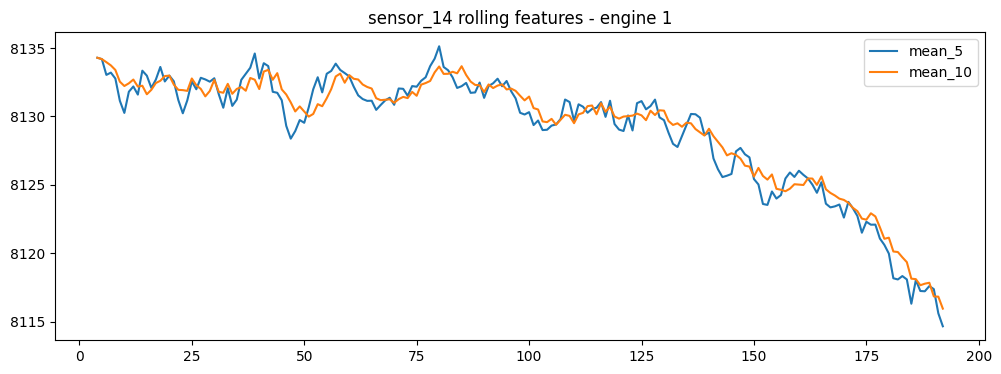

In [8]:
# checking if the engineered features look right
e1 = df_train_features[df_train_features['engine_number'] == 1]
plt.figure(figsize=(12, 4))
plt.plot(e1['cycle'], e1['sensor_14_mean_5'], label='mean_5')
plt.plot(e1['cycle'], e1['sensor_14_mean_10'], label='mean_10')
plt.title('sensor_14 rolling features - engine 1')
plt.legend()
plt.show()

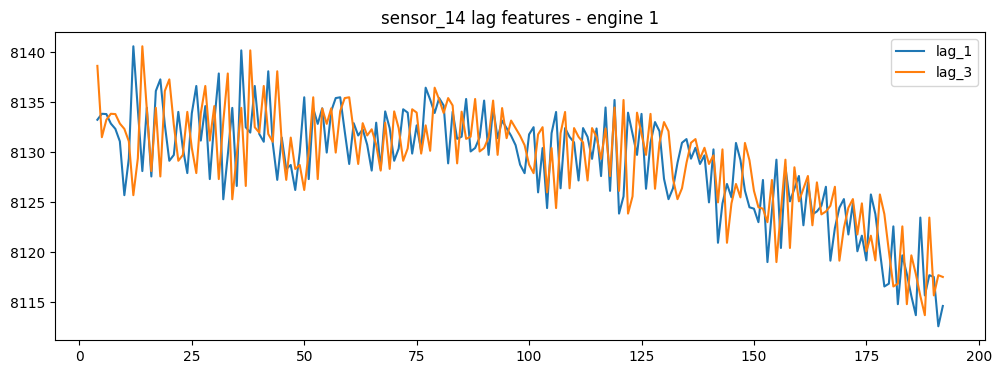

In [10]:
# check lag features
plt.figure(figsize=(12, 4))
plt.plot(e1['cycle'], e1['sensor_14_lag_1'], label='lag_1')
plt.plot(e1['cycle'], e1['sensor_14_lag_3'], label='lag_3')
plt.title('sensor_14 lag features - engine 1')
plt.legend()
plt.show()